In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

import pertpy as pt
import spVIPESmulti

np.random.seed(42)
torch.manual_seed(42)
sc.settings.set_figure_params(dpi=100, frameon=False)
torch.cuda.is_available()

# torch.set_float32_matmul_precision("medium")

True

In [2]:
adata = pt.data.kang_2018()

print(f"Shape           : {adata.shape}")
print(f"Cell types      : {adata.obs['cell_type'].nunique()}")
print()

Shape           : (24673, 15706)
Cell types      : 8



In [3]:
adata = adata[adata.obs["cell_type"] != "Megakaryocytes"]

In [4]:
adata.obs.columns

Index(['nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster',
       'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT',
       'integrated_snn_res.0.4', 'seurat_clusters'],
      dtype='object')

In [5]:
adata.obs["replicate"].value_counts()

replicate
patient_1015    5086
patient_1488    4576
patient_1256    4128
patient_1016    3357
patient_1244    3339
patient_101     2023
patient_107     1041
patient_1039     991
Name: count, dtype: int64

In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor="seurat_v3", batch_key="label")
adata = adata[:, adata.var["highly_variable"]].copy()

In [7]:
# Split into per-time-point AnnData objects
conditions = sorted(adata.obs["label"].unique())
adatas_dict = {}
for condition in conditions:
    sub = adata[adata.obs["label"] == condition].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[condition] = sub
    print(f"  {condition}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

  ctrl: (12252, 5000)
  stim: (12289, 5000)


In [8]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="label",
    label_key="cell_type",
    sample_key="replicate",
    condition_key="label",
    donor_key="replicate",
)

INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'label'                                                         
INFO     spVIPESmulti: Labels: Using 'cell_type' from adata.obs                                                    
INFO     spVIPESmulti: Samples: Using 'replicate' from adata.obs                                                   
INFO     spVIPESmulti: Conditions: Using 'label' from adata.obs                                                    
INFO     spVIPESmulti: Donors: Using 'replicate' from adata.obs                                                    
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


In [9]:
# Model hyperparameters
N_SHARED   = 30
N_PRIVATE  = 15
N_HIDDEN   = 256
DROPOUT    = 0.1
MAX_EPOCHS = 200
BATCH_SIZE = 1024
KL_WARMUP  = 80

model = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="full",
    disentangle_donor_shared_weight=0.5,
    disentangle_donor_private_weight=0.5,
    contrastive_weight=0.5,
    contrastive_temperature=0.25,
    use_nf_prior=False,
    use_batch_norm=True,
    use_layer_norm=False,
    dispersion="gene",
)
print(model)

INFO     spVIPESmulti: The model has been initialized                                                              


spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 30, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

In [10]:
?model.train

spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 30, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

Signature:
model.train(
    group_indices_list: Optional[list[list[int]]] = None,
    batch_size: Optional[int] = 128,
    max_epochs: Optional[int] = None,
    train_size: float = 0.9,
    validation_size: Optional[float] = None,
    early_stopping: bool = False,
    plan_kwargs: Optional[dict] = None,
    n_steps_kl_warmup: Optional[int] = None,
    n_epochs_kl_warmup: Optional[int] = 400,
    num_workers: int = 0,
    **trainer_kwargs,
) -> None
Docstring:
Train a multigroup spVIPESmulti model.

This method trains the model using a custom data splitter that handles
multiple groups of cells separately while maintaining the shared-private
latent space learning objective.

Parameters
----------
group_indices_list : list[list[int]], optional
    List of indices corresponding to each group of samples. Each inner list
    contains the indices for cells belonging to that specific group. If
    ``None``, values are inferred from ``adata.uns['groups_obs_indices']``.
max_epochs : int, optiona

In [11]:
# Get group indices from uns (canonical approach matching prepare_adatas output)
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", [len(g) for g in group_indices_list])

# Train with F1 orthogonality instrumentation enabled. Kang does not expose a
# separate technical batch here, so the F4 batch-shared head is intentionally off.
model.train(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,  # Leave 10% for validation
    early_stopping=True,
    n_epochs_kl_warmup=KL_WARMUP,
    compute_orthogonality_metric=True,
    orthogonality_groupby_keys=("condition", "donor"),
    orthogonality_min_cells_per_stratum=16,
    plan_kwargs={
        "lr_scheduler_type": "cosine",
        "lr_patience": 50,
    },
)

Group sizes: [12252, 12289]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


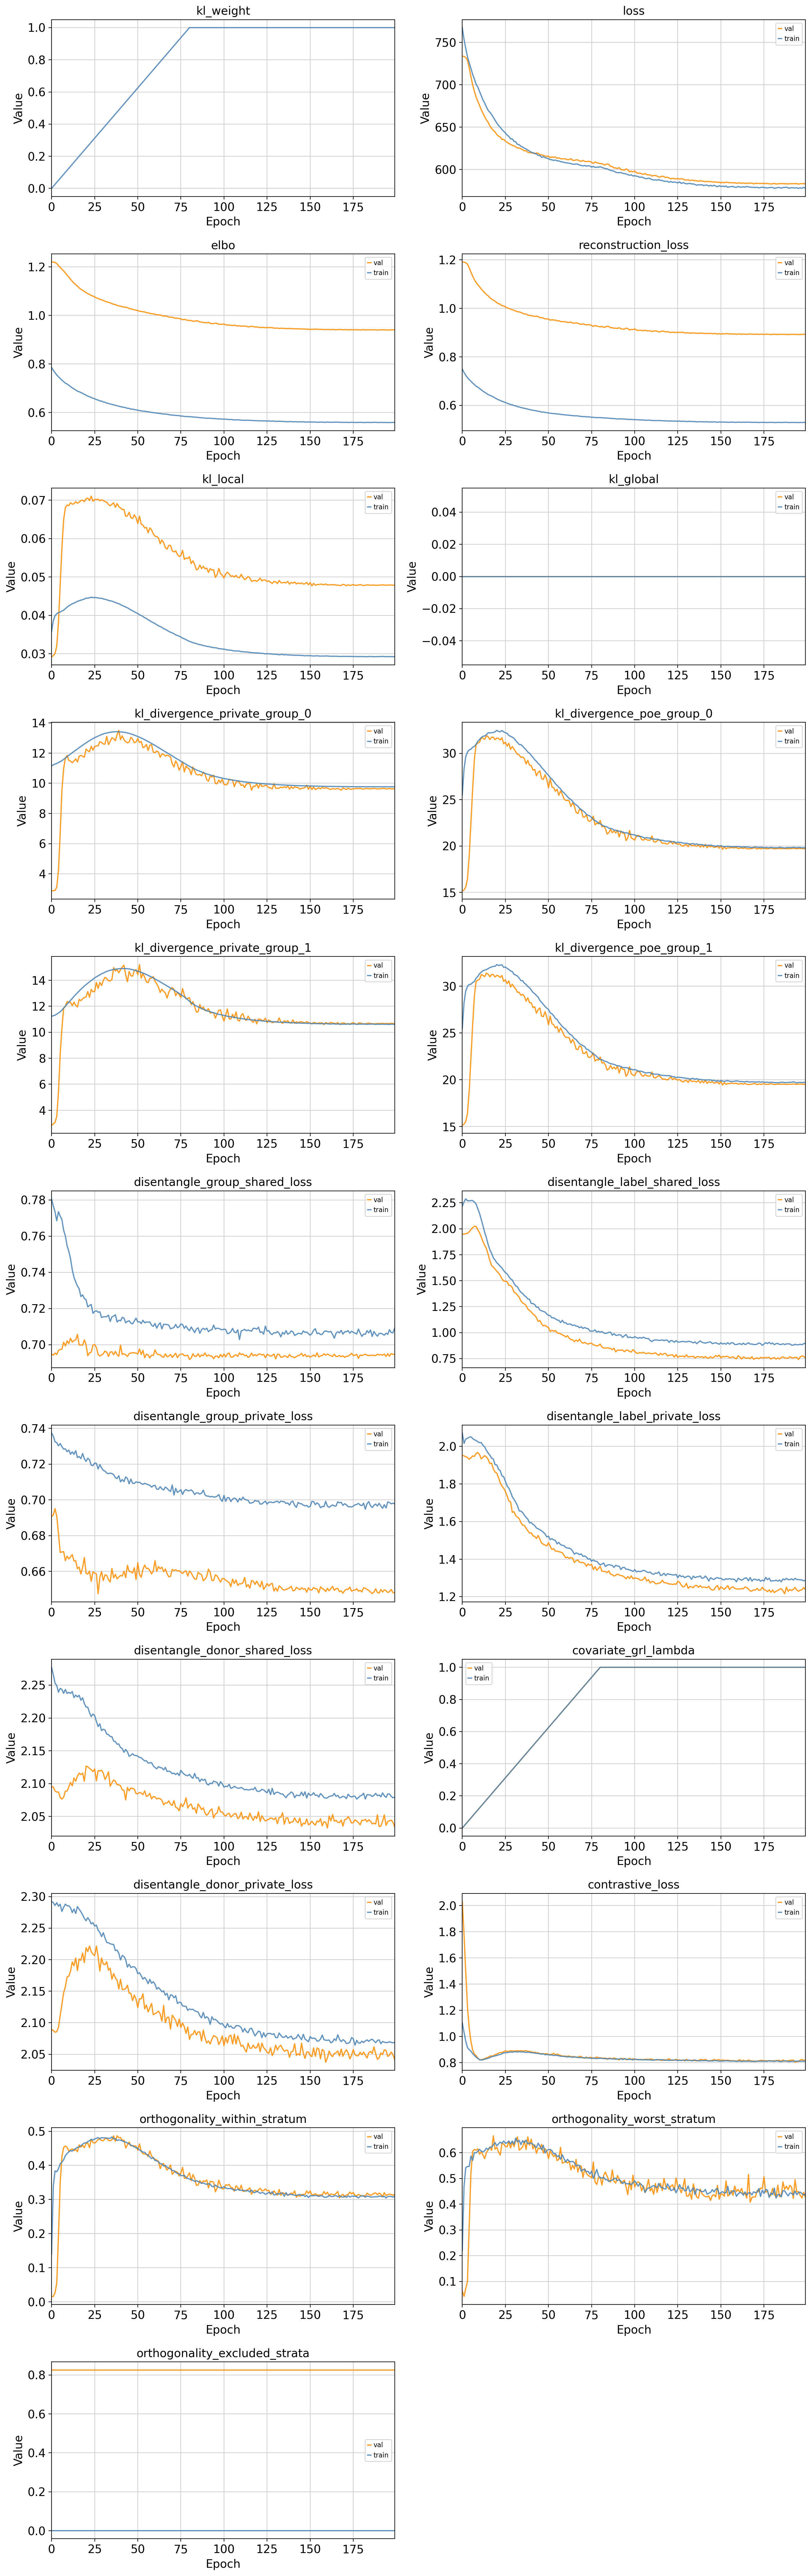

In [12]:
# Multi-panel training history — one panel per tracked metric
fig = spVIPESmulti.pl.training_curves(model)
plt.show()

In [13]:
latents = model.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
shared_by_group = latents.get("shared_reordered", latents["shared"])
private_by_group = latents.get("private_reordered", latents["private"])

latent_shared = np.zeros((adata_spv.n_obs, N_SHARED), dtype=np.float32)
latent_private = np.zeros((adata_spv.n_obs, N_PRIVATE), dtype=np.float32)
for group_idx, obs_idx in enumerate(group_indices_list):
    latent_shared[np.asarray(obs_idx)] = shared_by_group[group_idx]
    latent_private[np.asarray(obs_idx)] = private_by_group[group_idx]

latent_private_dataset1 = private_by_group[0]
latent_private_dataset2 = private_by_group[1]


def _probe_balanced_accuracy(x, y, seed=42):
    y = np.asarray(y).astype(str)
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return np.nan
    stratify = y if counts.min() >= 2 else None
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.3,
        random_state=seed,
        stratify=stratify,
    )
    clf = LogisticRegression(max_iter=500, class_weight="balanced")
    clf.fit(x_train, y_train)
    return balanced_accuracy_score(y_test, clf.predict(x_test))

probe_rows = []
for latent_name, x in {"shared": latent_shared, "private": latent_private}.items():
    for target_name, obs_key in {
        "condition": "label",
        "donor": "replicate",
        "cell_type": "cell_type",
    }.items():
        probe_rows.append({
            "latent": latent_name,
            "target": target_name,
            "balanced_accuracy": _probe_balanced_accuracy(x, adata_spv.obs[obs_key]),
        })

probe_df = pd.DataFrame(probe_rows)
probe_df.pivot(index="target", columns="latent", values="balanced_accuracy")

latent,private,shared
target,,
cell_type,0.538978,0.935970
condition,0.589796,0.498313
donor,0.166303,0.188099


In [14]:
adata_spv.obsm["X_spVIPES_shared"] = latent_shared
sc.pp.neighbors(adata_spv, use_rep="X_spVIPES_shared", key_added="spvipes_shared")
sc.tl.umap(adata_spv, neighbors_key="spvipes_shared", min_dist=1)
adata_spv.obsm["X_umap_shared"] = adata_spv.obsm["X_umap"].copy()

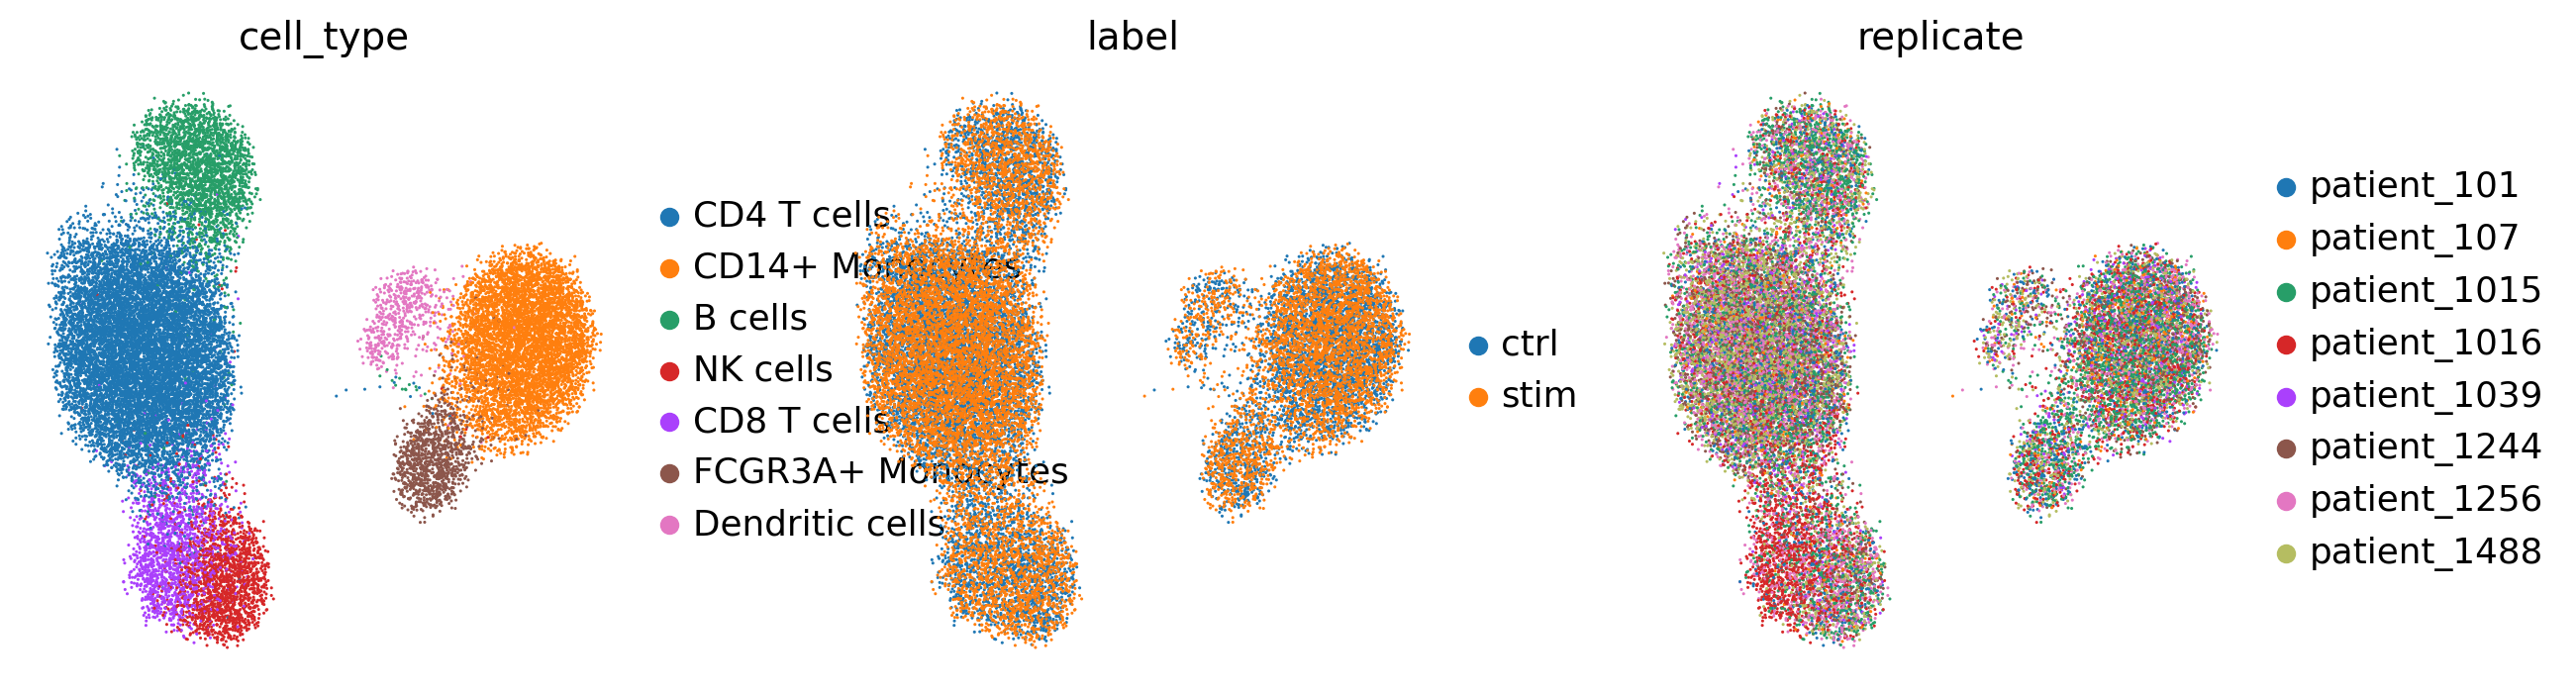

In [15]:
sc.pl.embedding(adata_spv, basis="X_umap_shared", color=["cell_type", "label", "replicate"])

In [16]:
adatas_ctrl = adatas_dict["ctrl"]
adatas_stim = adatas_dict["stim"]

adatas_ctrl.obsm["X_spvipes_private"] = private_by_group[conditions.index("ctrl")]
adatas_stim.obsm["X_spvipes_private"] = private_by_group[conditions.index("stim")]

In [17]:
sc.pp.neighbors(adatas_ctrl, use_rep="X_spvipes_private", key_added="spvipes_private")
sc.tl.umap(adatas_ctrl, neighbors_key="spvipes_private")

sc.pp.neighbors(adatas_stim, use_rep="X_spvipes_private", key_added="spvipes_private")
sc.tl.umap(adatas_stim, neighbors_key="spvipes_private")

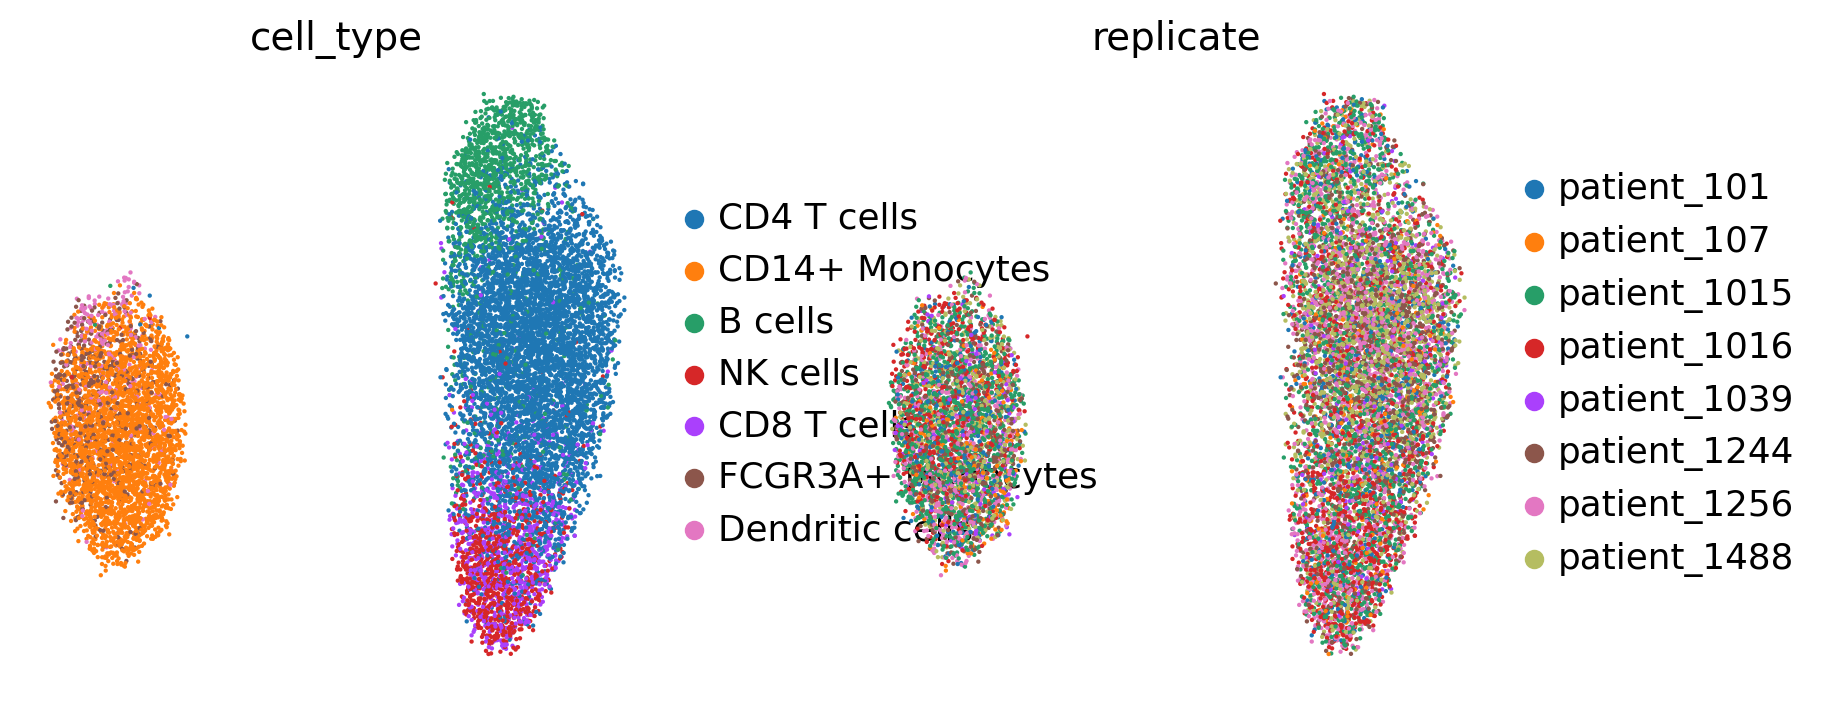

In [18]:
sc.pl.embedding(adatas_ctrl, basis="X_umap", color=["cell_type","replicate"])

In [19]:
ifn_beta_response_genes = [
    "IFNAR1",
    "IFNAR2",
    "IFNB1",
    "STAT1",
    "STAT2",
    "TYK2",
    "JAK1",
    "IRF9",
    "IRF1",
    "IRF7",
    "IRF3",
    "OAS1",
    "OAS2",
    "OAS3",
    "MX1",
    "MX2",
    "ISG15",
    "RSAD2",
    "IFI27",
    "IFI44",
    "IFI44L",
    "IFIT1",
    "IFIT2",
    "IFIT3",
    "IFIT5",
    "IFITM1",
    "IFITM2",
    "IFITM3",
    "IFI6",
    "IFIH1",
    "IFIT1B",
    "IFITM10",
    "OASL",
    "BST2",
    "IFITM5"
]

In [20]:
sc.tl.score_genes(adatas_ctrl, gene_list=ifn_beta_response_genes, score_name="ISG_score")

       'IFIT1B', 'IFITM10', 'IFITM5'],
      dtype='object')


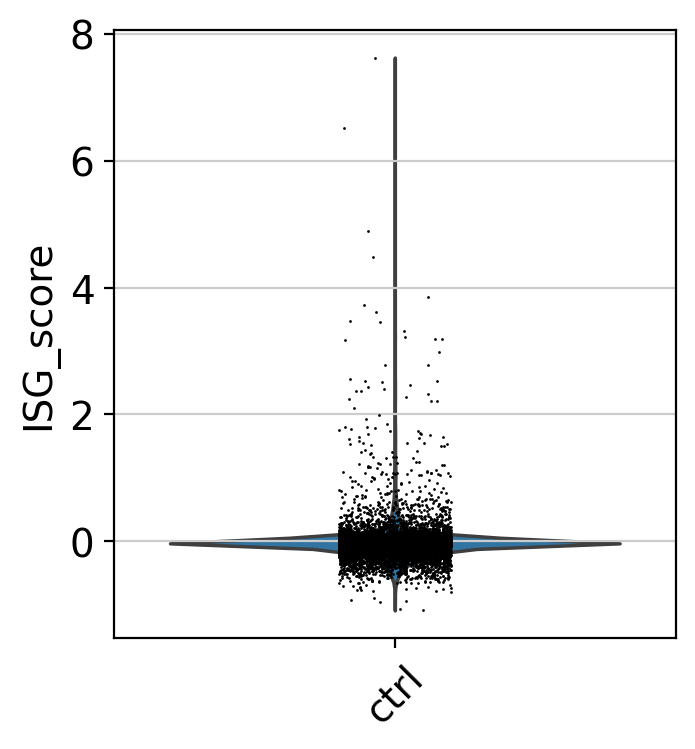

In [21]:
sc.pl.violin(adatas_ctrl, groupby="label", keys="ISG_score", rotation=45)

In [22]:
sc.tl.score_genes(adatas_stim, gene_list=ifn_beta_response_genes, score_name="ISG_score")

       'IFIT1B', 'IFITM10', 'IFITM5'],
      dtype='object')


In [23]:
adatas_stim.obs["ifnb_responsive"] = adatas_stim.obs["ISG_score"] > 5

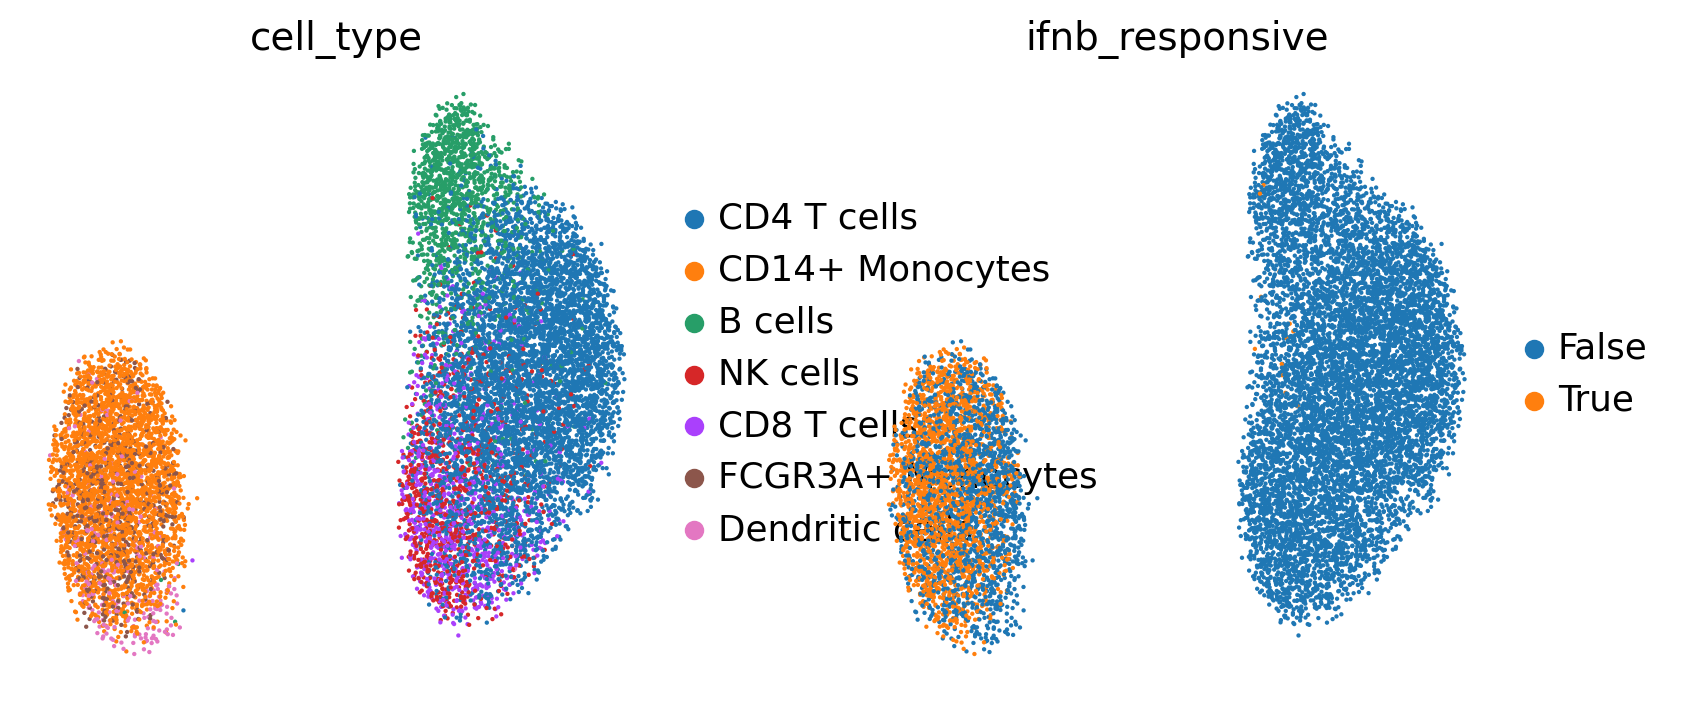

In [24]:
sc.pl.embedding(adatas_stim, basis="X_umap", color=["cell_type","ifnb_responsive"])